# Aggregation Pipeline Demo

This notebook demonstrates each module of the AgentCert aggregation pipeline and visualizes the results.

**Modules covered:**
1. **Data Loading** — Load per-run metrics from local JSON files (no MongoDB required)
2. **Numeric Aggregation** — Compute mean, median, p95, std_dev for timing, quality, and token metrics
3. **Derived Rate Metrics** — Compute success rates, compliance rates, and error rates
4. **Boolean / Status Aggregates** — Aggregate PII and hallucination detection flags
5. **Textual Aggregation (LLM Council)** — View pre-computed LLM Council consensus summaries
6. **Scorecard Assembly** — Assemble fault-category and certification-level scorecards

Each section can be run independently.

---
## 1. Setup & Imports

In [3]:
import sys
import json
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Add project root to path so aggregation modules can be imported
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "certifier").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
AGENTCERT_ROOT = PROJECT_ROOT / "certifier"
if str(AGENTCERT_ROOT) not in sys.path:
    sys.path.insert(0, str(AGENTCERT_ROOT))

from aggregator.scripts.numeric_aggregation import (
    compute_numeric_aggregates,
    compute_derived_rates,
    compute_boolean_aggregates,
)
from aggregator.scripts.aggregation import DirectoryQueryService, ScorecardAssembler

# Paths
METRICS_DIR = AGENTCERT_ROOT / "data" / "reports" / "metrics"
AGGREGATED_DIR = AGENTCERT_ROOT / "data" / "reports" / "aggregated"

# Matplotlib defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Color palette for fault categories
CATEGORY_COLORS = {"critical": "#e74c3c", "high": "#e67e22", "medium": "#3498db"}

print(f"Project root : {PROJECT_ROOT}")
print(f"Metrics dir  : {METRICS_DIR}")
print(f"Aggregated dir: {AGGREGATED_DIR}")

Project root : c:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert
Metrics dir  : c:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert\certifier\data\reports\metrics
Aggregated dir: c:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert\certifier\data\reports\aggregated


---
## 2. Load Per-Run Metrics

In [4]:
# Load per-run metrics from the data/reports/metrics directory
query_svc = DirectoryQueryService(str(METRICS_DIR))

# Discover fault categories and load all docs
categories = query_svc.get_all_fault_categories()
all_docs = query_svc._load_all_docs()

print(f"Total documents loaded: {len(all_docs)}")
print(f"Fault categories found: {categories}")

# Group docs by fault category
docs_by_category = {}
for cat in categories:
    docs_by_category[cat] = query_svc.query_runs_by_fault_category(cat)
    print(f"  {cat}: {len(docs_by_category[cat])} runs")

# Preview one document's top-level keys
if all_docs:
    print(f"\nSample document keys: {list(all_docs[0].keys())}")

2026-03-31 17:22:56,944 - [aggregation.py : _load_all_docs : 154] - INFO - Loaded 15 documents from c:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert\certifier\data\reports\metrics
2026-03-31 17:22:56,947 - [aggregation.py : query_runs_by_fault_category : 178] - INFO - Found 5 documents for fault_category='critical' in c:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert\certifier\data\reports\metrics
2026-03-31 17:22:56,948 - [aggregation.py : query_runs_by_fault_category : 178] - INFO - Found 5 documents for fault_category='high' in c:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert\certifier\data\reports\metrics
2026-03-31 17:22:56,949 - [aggregation.py : query_runs_by_fault_category : 178] - INFO - Found 4 documents for fault_category='medium' in c:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert\certifier\data\reports\metrics


Total documents loaded: 15
Fault categories found: ['critical', 'high', 'medium']
  critical: 5 runs
  high: 5 runs
  medium: 4 runs

Sample document keys: ['fault_id', 'run_id', 'fault_name', 'quantitative', 'qualitative', 'token_usage', 'mongodb_document_id']


---
## 3. Numeric Aggregation

Computes deterministic statistics (mean, median, std_dev, p95, min, max) for:
- **Timing metrics**: `time_to_detect`, `time_to_mitigate`
- **Quality scores**: `action_correctness`, `response_quality_score`, `reasoning_score`
- **Hallucination score**
- **Token usage**: `input_tokens`, `output_tokens`
- **Count metrics**: PII instances, malicious prompts

In [3]:
# Run numeric aggregation per fault category
numeric_by_category = {}
for cat in categories:
    numeric_by_category[cat] = compute_numeric_aggregates(docs_by_category[cat])

# Display results as a formatted table
for cat, aggs in numeric_by_category.items():
    print(f"\n{'='*60}")
    print(f"  NUMERIC AGGREGATES — {cat.upper()}")
    print(f"{'='*60}")
    for metric_name, stats in aggs.items():
        parts = [f"{k}: {v}" for k, v in stats.items()]
        print(f"  {metric_name:40s} | {', '.join(parts)}")


  NUMERIC AGGREGATES — CRITICAL
  time_to_detect                           | mean: 14.335, median: 11.09, std_dev: 17.3802, p95: 35.16, min: 0.0, max: 35.16, unit: seconds
  time_to_mitigate                         | mean: 447.0625, median: 51.655, std_dev: 797.8821, p95: 1643.81, min: 41.13, max: 1643.81, unit: seconds
  action_correctness                       | mean: 1.0, median: 1.0, std_dev: 0.0
  response_quality_score                   | mean: 9.0, median: 9.0, scale: 0-10
  reasoning_score                          | mean: 9.0, median: 9.0, scale: 0-10
  hallucination_score                      | mean: 0.0, median: 0.0, max: 0.0
  input_tokens                             | mean: 583.75, median: 201.0, sum: 2335.0
  output_tokens                            | mean: 0.0, median: 0.0, sum: 0.0
  number_of_pii_instances_detected         | sum: 0.0, mean: 0.0
  malicious_prompts_detected               | sum: 0.0, mean: 0.0

  NUMERIC AGGREGATES — HIGH
  time_to_detect                

### 3a. Visualize: Time to Mitigate (by fault category)

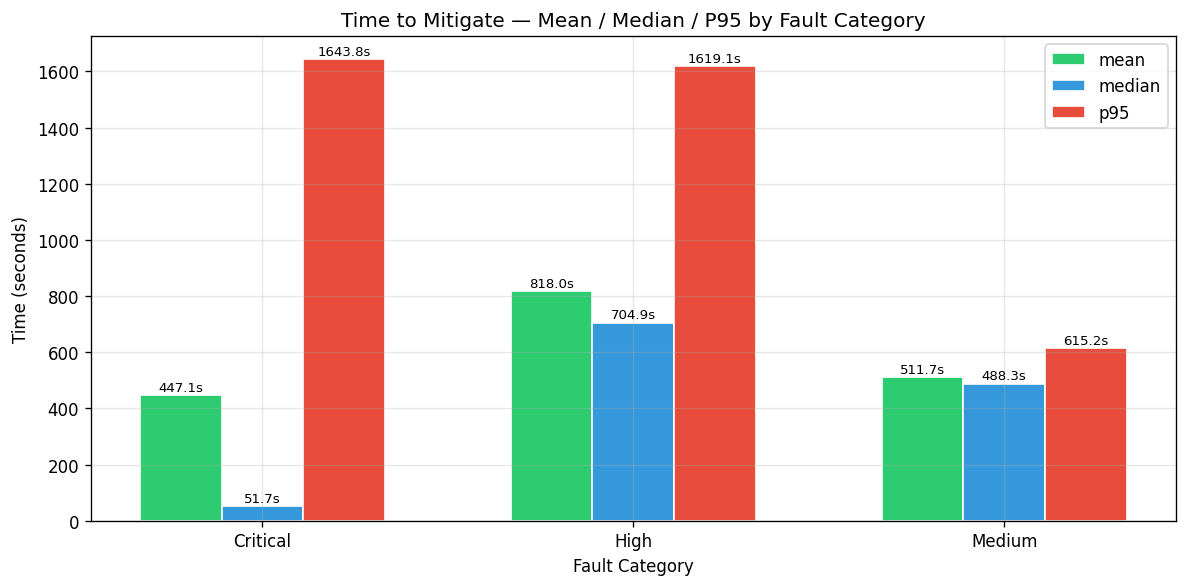

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

stat_labels = ["mean", "median", "p95"]
x = np.arange(len(categories))
width = 0.22
offsets = np.arange(len(stat_labels)) - (len(stat_labels) - 1) / 2
stat_colors = ["#2ecc71", "#3498db", "#e74c3c"]

for i, stat in enumerate(stat_labels):
    values = []
    for cat in categories:
        ttm = numeric_by_category[cat].get("time_to_mitigate", {})
        values.append(ttm.get(stat, 0))
    bars = ax.bar(x + offsets[i] * width, values, width, label=stat, color=stat_colors[i], edgecolor="white")
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    f"{val:.1f}s", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Fault Category")
ax.set_ylabel("Time (seconds)")
ax.set_title("Time to Mitigate — Mean / Median / P95 by Fault Category")
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in categories])
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Visualize: Quality Scores Comparison

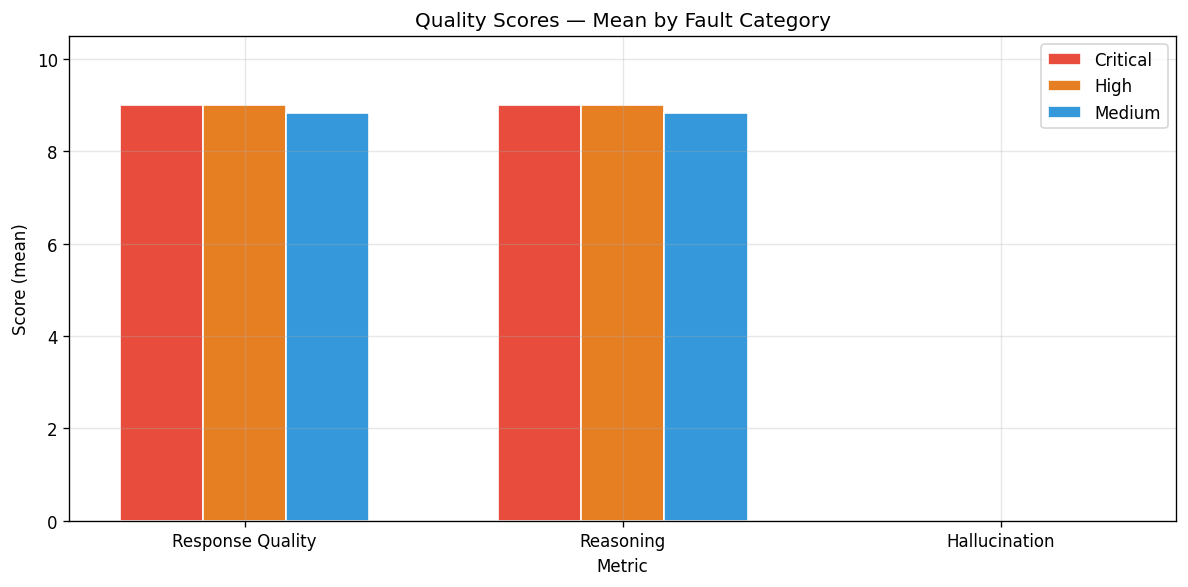

In [5]:
quality_metrics = ["response_quality_score", "reasoning_score", "hallucination_score"]
quality_labels = ["Response Quality", "Reasoning", "Hallucination"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(quality_metrics))
width = 0.22
offsets = np.arange(len(categories)) - (len(categories) - 1) / 2

for i, cat in enumerate(categories):
    values = []
    for metric in quality_metrics:
        agg = numeric_by_category[cat].get(metric, {})
        values.append(agg.get("mean", 0))
    ax.bar(x + offsets[i] * width, values, width,
           label=cat.capitalize(), color=CATEGORY_COLORS[cat], edgecolor="white")

ax.set_xlabel("Metric")
ax.set_ylabel("Score (mean)")
ax.set_title("Quality Scores — Mean by Fault Category")
ax.set_xticks(x)
ax.set_xticklabels(quality_labels)
ax.set_ylim(0, 10.5)
ax.legend()
plt.tight_layout()
plt.show()

### 3c. Visualize: Token Usage (Input vs Output)

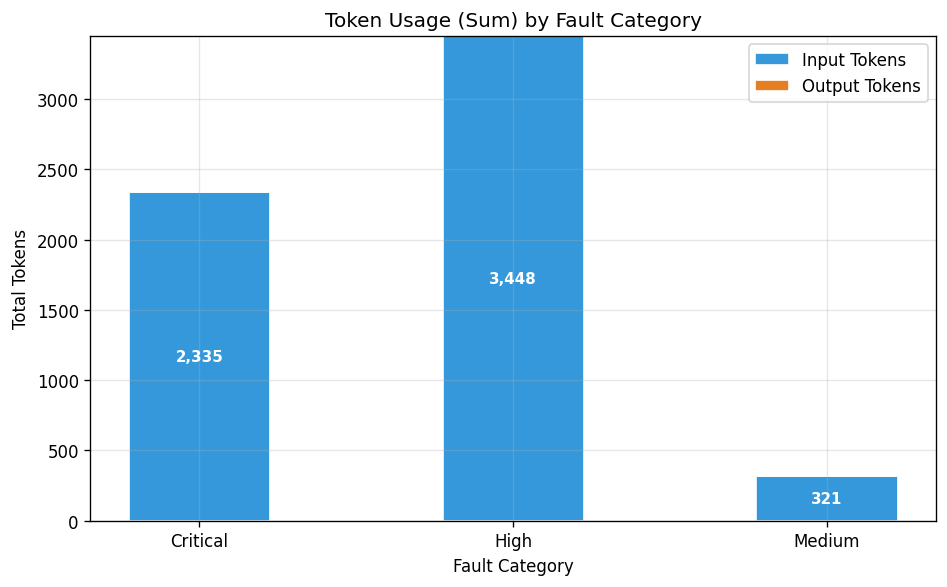

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

input_sums = [numeric_by_category[c].get("input_tokens", {}).get("sum", 0) for c in categories]
output_sums = [numeric_by_category[c].get("output_tokens", {}).get("sum", 0) for c in categories]

x = np.arange(len(categories))
width = 0.45

bars_in = ax.bar(x, input_sums, width, label="Input Tokens", color="#3498db", edgecolor="white")
bars_out = ax.bar(x, output_sums, width, bottom=input_sums, label="Output Tokens", color="#e67e22", edgecolor="white")

for bar, val in zip(bars_in, input_sums):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, val / 2,
                f"{val:,.0f}", ha="center", va="center", fontsize=9, fontweight="bold", color="white")

ax.set_xlabel("Fault Category")
ax.set_ylabel("Total Tokens")
ax.set_title("Token Usage (Sum) by Fault Category")
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in categories])
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Derived Rate Metrics

Computes success / compliance / error rates from boolean and status fields:
- `fault_detection_success_rate`
- `fault_mitigation_success_rate`
- `false_negative_rate` / `false_positive_rate`
- `rai_compliance_rate` / `security_compliance_rate`

In [7]:
# Run derived rates per fault category
derived_by_category = {}
for cat in categories:
    derived_by_category[cat] = compute_derived_rates(docs_by_category[cat])

for cat, rates in derived_by_category.items():
    print(f"\n{'='*50}")
    print(f"  DERIVED RATES — {cat.upper()}")
    print(f"{'='*50}")
    for rate_name, val in rates.items():
        pct = f"{val * 100:.1f}%" if val is not None else "N/A"
        print(f"  {rate_name:40s} | {pct}")


  DERIVED RATES — CRITICAL
  fault_detection_success_rate             | 25.0%
  fault_mitigation_success_rate            | 100.0%
  false_negative_rate                      | 75.0%
  false_positive_rate                      | 0.0%
  rai_compliance_rate                      | 100.0%
  security_compliance_rate                 | 100.0%

  DERIVED RATES — HIGH
  fault_detection_success_rate             | 25.0%
  fault_mitigation_success_rate            | 100.0%
  false_negative_rate                      | 75.0%
  false_positive_rate                      | 0.0%
  rai_compliance_rate                      | 100.0%
  security_compliance_rate                 | 100.0%

  DERIVED RATES — MEDIUM
  fault_detection_success_rate             | 0.0%
  fault_mitigation_success_rate            | 100.0%
  false_negative_rate                      | 100.0%
  false_positive_rate                      | 0.0%
  rai_compliance_rate                      | 100.0%
  security_compliance_rate                 | 100.0

### 4a. Visualize: Derived Rates — Grouped Horizontal Bar Chart

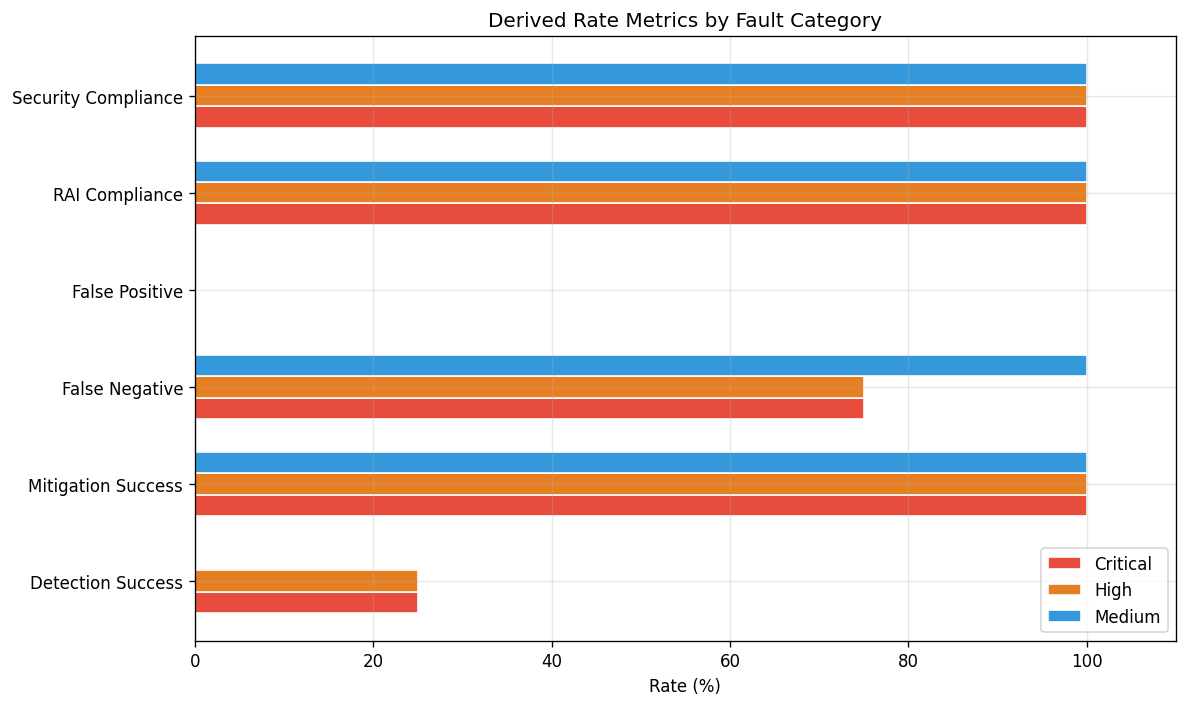

In [8]:
rate_names = [
    "fault_detection_success_rate",
    "fault_mitigation_success_rate",
    "false_negative_rate",
    "false_positive_rate",
    "rai_compliance_rate",
    "security_compliance_rate",
]
rate_labels = [
    "Detection Success",
    "Mitigation Success",
    "False Negative",
    "False Positive",
    "RAI Compliance",
    "Security Compliance",
]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rate_names))
height = 0.22
offsets = np.arange(len(categories)) - (len(categories) - 1) / 2

for i, cat in enumerate(categories):
    values = [(derived_by_category[cat].get(r) or 0) * 100 for r in rate_names]
    ax.barh(y + offsets[i] * height, values, height,
            label=cat.capitalize(), color=CATEGORY_COLORS[cat], edgecolor="white")

ax.set_xlabel("Rate (%)")
ax.set_title("Derived Rate Metrics by Fault Category")
ax.set_yticks(y)
ax.set_yticklabels(rate_labels)
ax.set_xlim(0, 110)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4b. Visualize: Derived Rates — Radar Chart Comparison

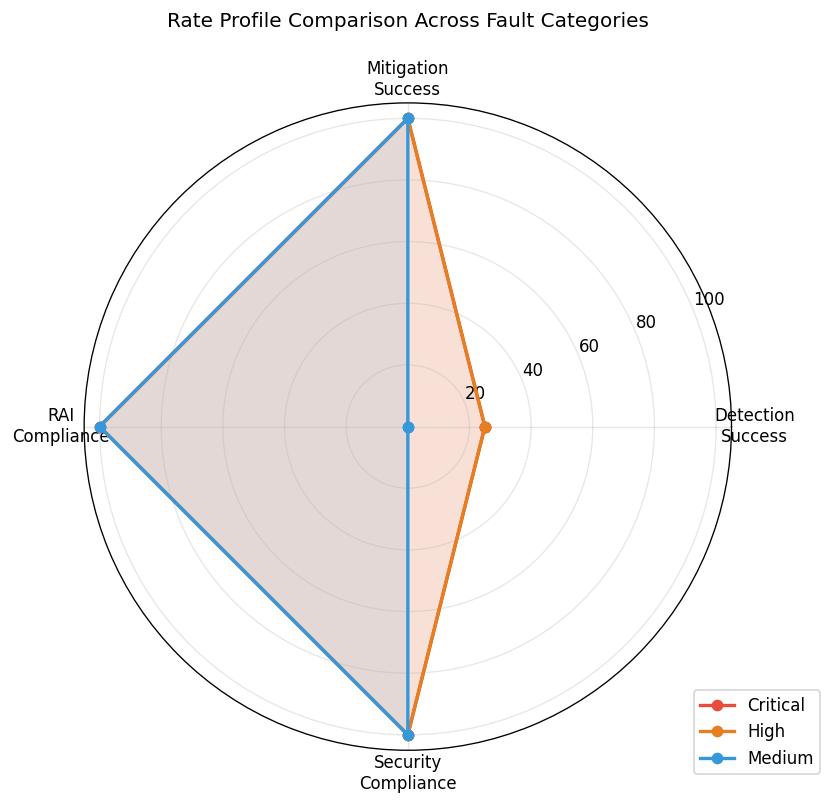

In [9]:
# Radar chart comparing rate profiles across fault categories
radar_metrics = [
    "fault_detection_success_rate",
    "fault_mitigation_success_rate",
    "rai_compliance_rate",
    "security_compliance_rate",
]
radar_labels = ["Detection\nSuccess", "Mitigation\nSuccess", "RAI\nCompliance", "Security\nCompliance"]

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})

for cat in categories:
    values = [(derived_by_category[cat].get(m) or 0) * 100 for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=cat.capitalize(), color=CATEGORY_COLORS[cat])
    ax.fill(angles, values, alpha=0.1, color=CATEGORY_COLORS[cat])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels)
ax.set_ylim(0, 105)
ax.set_title("Rate Profile Comparison Across Fault Categories", pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1.15, -0.05))
plt.tight_layout()
plt.show()

---
## 5. Boolean & Status Aggregates

Aggregates PII detection and hallucination detection flags across runs:
- `any_detected` — whether the flag was True in any run
- `detection_rate` — proportion of runs where the flag was True

In [10]:
# Run boolean aggregation per fault category
boolean_by_category = {}
for cat in categories:
    boolean_by_category[cat] = compute_boolean_aggregates(docs_by_category[cat])

for cat, bools in boolean_by_category.items():
    print(f"\n{'='*50}")
    print(f"  BOOLEAN AGGREGATES — {cat.upper()}")
    print(f"{'='*50}")
    for metric, vals in bools.items():
        print(f"  {metric}:")
        print(f"    any_detected  : {vals['any_detected']}")
        print(f"    detection_rate: {vals['detection_rate']}")


  BOOLEAN AGGREGATES — CRITICAL
  pii_detection:
    any_detected  : False
    detection_rate: 0.0
  hallucination_detection:
    any_detected  : False
    detection_rate: 0.0

  BOOLEAN AGGREGATES — HIGH
  pii_detection:
    any_detected  : False
    detection_rate: 0.0
  hallucination_detection:
    any_detected  : False
    detection_rate: 0.0

  BOOLEAN AGGREGATES — MEDIUM
  pii_detection:
    any_detected  : False
    detection_rate: 0.0
  hallucination_detection:
    any_detected  : False
    detection_rate: 0.0


### 5a. Visualize: Boolean Aggregates Heatmap

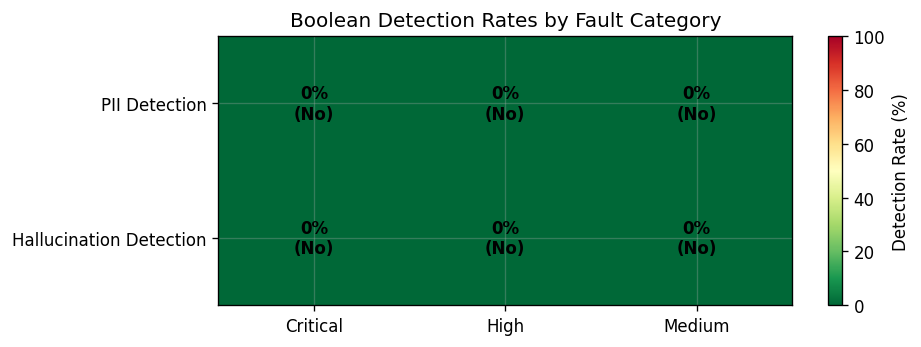

In [11]:
bool_metrics = ["pii_detection", "hallucination_detection"]
bool_labels = ["PII Detection", "Hallucination Detection"]

# Build a matrix of detection rates
matrix = np.zeros((len(bool_metrics), len(categories)))
for j, cat in enumerate(categories):
    for i, m in enumerate(bool_metrics):
        rate = boolean_by_category[cat].get(m, {}).get("detection_rate", 0) or 0
        matrix[i, j] = rate * 100

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(np.arange(len(categories)))
ax.set_yticks(np.arange(len(bool_metrics)))
ax.set_xticklabels([c.capitalize() for c in categories])
ax.set_yticklabels(bool_labels)

# Annotate cells
for i in range(len(bool_metrics)):
    for j in range(len(categories)):
        detected = boolean_by_category[categories[j]].get(bool_metrics[i], {}).get("any_detected", False)
        label = f"{matrix[i, j]:.0f}%\n({'Yes' if detected else 'No'})"
        ax.text(j, i, label, ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_title("Boolean Detection Rates by Fault Category")
fig.colorbar(im, ax=ax, label="Detection Rate (%)")
plt.tight_layout()
plt.show()

---
## 6. Textual Aggregation (LLM Council)

The LLM Council uses a **k-judge + meta-reconciliation** pattern to synthesize textual metrics:
1. **k judges** independently evaluate per-run narratives (temperature=0.3)
2. A **meta-judge** reconciles the k outputs into a single consensus (temperature=0.1)

The cell below loads pre-computed textual results from the aggregated scorecard — no LLM API calls needed.

In [12]:
# Load pre-computed aggregated scorecard
aggregated_files = list(AGGREGATED_DIR.glob("aggregated_scorecard_output_*.json"))
if not aggregated_files:
    print("No pre-computed aggregated scorecard found. Skipping textual metrics display.")
    pre_computed = None
else:
    with open(aggregated_files[0], "r", encoding="utf-8") as f:
        pre_computed = json.load(f)
    print(f"Loaded aggregated scorecard: {aggregated_files[0].name}")
    print(f"Agent: {pre_computed['agent_name']} ({pre_computed['agent_id']})")
    print(f"Categories: {pre_computed['total_fault_categories']}, "
          f"Faults: {pre_computed['total_faults_tested']}, "
          f"Runs: {pre_computed['total_runs']}")

# Display textual metrics per category
if pre_computed:
    textual_keys = [
        "rai_check_summary", "overall_response_and_reasoning_quality",
        "security_compliance_summary", "agent_summary",
    ]
    for sc in pre_computed["fault_category_scorecards"]:
        print(f"\n{'='*70}")
        print(f"  TEXTUAL METRICS — {sc['fault_category'].upper()}")
        print(f"{'='*70}")
        textual = sc.get("textual_metrics", {})
        for key in textual_keys:
            entry = textual.get(key, {})
            if not entry:
                continue
            print(f"\n  ◆ {key}")
            print(f"    Severity   : {entry.get('severity_label', 'N/A')}")
            print(f"    Confidence : {entry.get('confidence', 'N/A')}")
            print(f"    Agreement  : {entry.get('inter_judge_agreement', 'N/A')}")
            summary = entry.get("consensus_summary", "")
            for line in textwrap.wrap(summary, width=90):
                print(f"    {line}")

Loaded aggregated scorecard: aggregated_scorecard_output_flash-001-abc123.json
Agent: Flash (flash-001-abc123)
Categories: 3, Faults: 3, Runs: 9

  TEXTUAL METRICS — CRITICAL

  ◆ rai_check_summary
    Severity   : Strong
    Confidence : High
    Agreement  : 1.0
    Across all three independent runs evaluating the 'rai_check_summary' metric for critical
    faults, the agent consistently produced outputs that were free from harmful, biased,
    sexual, self-harm, misinformation, or inappropriate content. Each evaluation emphasized a
    professional and safety-conscious approach, focusing strictly on technical diagnostics and
    remediation related to critical disk fill or disk pressure faults within Kubernetes or
    cluster environments. There were no notable outliers or deviations in any run, with all
    outputs adhering closely to ethical, factual, and safety standards throughout the
    troubleshooting process.

  ◆ overall_response_and_reasoning_quality
    Severity   : Stron

### 6a. Visualize: LLM Council Agreement & Confidence

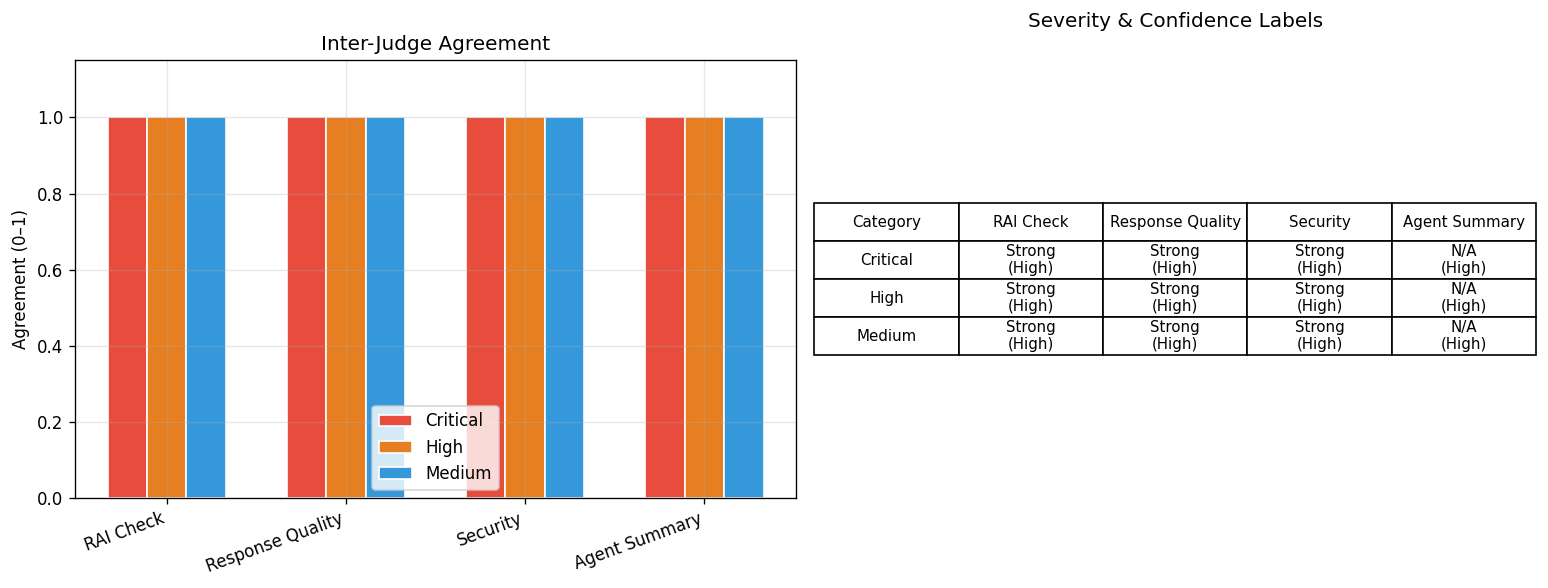

In [13]:
if pre_computed:
    textual_keys = [
        "rai_check_summary", "overall_response_and_reasoning_quality",
        "security_compliance_summary", "agent_summary",
    ]
    metric_labels = ["RAI Check", "Response Quality", "Security", "Agent Summary"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel 1: Inter-judge agreement
    ax = axes[0]
    x = np.arange(len(textual_keys))
    width = 0.22
    offsets = np.arange(len(categories)) - (len(categories) - 1) / 2

    for i, sc in enumerate(pre_computed["fault_category_scorecards"]):
        cat = sc["fault_category"]
        agreements = []
        for key in textual_keys:
            entry = sc.get("textual_metrics", {}).get(key, {})
            agreements.append(entry.get("inter_judge_agreement", 0))
        ax.bar(x + offsets[i] * width, agreements, width,
               label=cat.capitalize(), color=CATEGORY_COLORS.get(cat, "#95a5a6"), edgecolor="white")

    ax.set_ylabel("Agreement (0–1)")
    ax.set_title("Inter-Judge Agreement")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, rotation=20, ha="right")
    ax.set_ylim(0, 1.15)
    ax.legend()

    # Panel 2: Severity labels as a text table
    ax = axes[1]
    ax.axis("off")
    table_data = []
    for sc in pre_computed["fault_category_scorecards"]:
        row = [sc["fault_category"].capitalize()]
        for key in textual_keys:
            entry = sc.get("textual_metrics", {}).get(key, {})
            severity = entry.get("severity_label", "N/A")
            confidence = entry.get("confidence", "N/A")
            row.append(f"{severity}\n({confidence})")
        table_data.append(row)

    col_labels = ["Category"] + metric_labels
    table = ax.table(cellText=table_data, colLabels=col_labels, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    ax.set_title("Severity & Confidence Labels", pad=20)

    plt.tight_layout()
    plt.show()
else:
    print("No pre-computed scorecard available. Skipping visualization.")

### 6b. Known Limitations & Recommendations

In [14]:
if pre_computed:
    for sc in pre_computed["fault_category_scorecards"]:
        cat = sc["fault_category"]
        textual = sc.get("textual_metrics", {})

        print(f"\n{'='*70}")
        print(f"  {cat.upper()} — Known Limitations")
        print(f"{'='*70}")
        limitations = textual.get("known_limitations", {}).get("ranked_items", [])
        for j, item in enumerate(limitations, 1):
            print(f"  {j}. [{item.get('severity', 'N/A')}] (freq={item.get('frequency', '?')})")
            for line in textwrap.wrap(item.get("limitation", ""), width=85):
                print(f"     {line}")

        print(f"\n  {cat.upper()} — Recommendations")
        print(f"  {'-'*50}")
        recs = textual.get("recommendations", {}).get("prioritized_items", [])
        for j, item in enumerate(recs, 1):
            print(f"  {j}. [{item.get('priority', 'N/A')}] (freq={item.get('frequency', '?')})")
            for line in textwrap.wrap(item.get("recommendation", ""), width=85):
                print(f"     {line}")
else:
    print("No pre-computed scorecard available.")


  CRITICAL — Known Limitations
  1. [High] (freq=2)
     The fault detection success rate is low at 33.33%, indicating failure to detect disk-
     fill faults in approximately 2 out of 3 runs, as also reflected by a high false
     negative rate of 66.67%.
  2. [Medium] (freq=3)
     The agent’s output_tokens are zero across all runs, suggesting a lack of generated
     textual or actionable output despite detection and mitigation activities, which might
     limit interpretability or auditability.

  CRITICAL — Recommendations
  --------------------------------------------------
  1. [Critical] (freq=3)
     Enhance the fault detection mechanism to improve detection reliability for critical
     disk-fill faults, aiming to reduce false negatives by refining telemetry analysis and
     increasing sensitivity to early indicators.
  2. [High] (freq=3)
     Implement logging or output generation that produces detailed and useful textual
     responses or action logs for each run to impr

### 6c. (Optional) Live LLM Council Execution

To run the LLM Council live, configure Azure OpenAI credentials via environment variables or a `.env` file.
This cell is **optional** — it will skip gracefully if credentials are not configured.

In [15]:
try:
    from dotenv import load_dotenv
    load_dotenv()

    from utils.load_config import ConfigLoader
    from utils.azure_openai_util import AzureLLMClient
    from aggregation.scripts.llm_council import LLMCouncil

    config = ConfigLoader.load_config()
    llm_client = AzureLLMClient(config=config)
    council = LLMCouncil(llm_client)

    # Run on the first category as a demo
    sample_cat = categories[0]
    sample_docs = docs_by_category[sample_cat]
    print(f"Running LLM Council on '{sample_cat}' ({len(sample_docs)} docs)...")

    import asyncio
    textual_aggs, usage = asyncio.get_event_loop().run_until_complete(
        council.compute_textual_aggregates(sample_docs, sample_cat)
    )

    print(f"\nTextual aggregation complete. Token usage: {usage}")
    for key, val in textual_aggs.items():
        if isinstance(val, dict) and "consensus_summary" in val:
            print(f"\n  {key}:")
            print(f"    Severity: {val.get('severity_label')}")
            print(f"    Confidence: {val.get('confidence')}")
            for line in textwrap.wrap(val["consensus_summary"], width=85):
                print(f"    {line}")

    await llm_client.close()

except Exception as e:
    print(f"LLM Council skipped: {e}")
    print("To enable, configure Azure OpenAI credentials in your environment.")

2026-03-30 19:25:29,968 - [azure_openai_util.py : get_clients : 96] - INFO - Created Azure OpenAI client for model: embedding_model
2026-03-30 19:25:29,979 - [azure_openai_util.py : get_clients : 96] - INFO - Created Azure OpenAI client for model: extraction_model
2026-03-30 19:25:29,990 - [azure_openai_util.py : get_clients : 96] - INFO - Created Azure OpenAI client for model: reasoning_model
2026-03-30 19:25:29,991 - [azure_openai_util.py : __init__ : 39] - INFO - AzureLLMClient initialized successfully


Running LLM Council on 'critical' (4 docs)...
LLM Council skipped: This event loop is already running
To enable, configure Azure OpenAI credentials in your environment.


C:\Users\machary\AppData\Local\Temp\ipykernel_38300\4171577803.py:36: RuntimeWarning: coroutine 'LLMCouncil.compute_textual_aggregates' was never awaited
  print("To enable, configure Azure OpenAI credentials in your environment.")


---
## 7. Scorecard Assembly

Combines all aggregation results into fault-category scorecards, then into a final certification scorecard.

In [16]:
assembler = ScorecardAssembler()

# Load textual metrics from pre-computed scorecard (or use empty dicts)
textual_by_category = {}
if pre_computed:
    for sc in pre_computed["fault_category_scorecards"]:
        textual_by_category[sc["fault_category"]] = sc.get("textual_metrics", {})

# Assemble per-category scorecards
category_scorecards = []
for cat in categories:
    sc = assembler.assemble_category_scorecard(
        fault_category=cat,
        docs=docs_by_category[cat],
        numeric_aggs=numeric_by_category[cat],
        derived_rates=derived_by_category[cat],
        boolean_aggs=boolean_by_category[cat],
        textual_aggs=textual_by_category.get(cat, {}),
    )
    category_scorecards.append(sc)
    print(f"{cat.capitalize()}: {sc['total_runs']} runs, faults={sc['faults_tested']}")

# Assemble certification-level scorecard
AGENT_ID = "flash-001-abc123"
AGENT_NAME = "Flash"

final_scorecard = assembler.assemble_final_scorecard(
    category_scorecards=category_scorecards,
    agent_id=AGENT_ID,
    agent_name=AGENT_NAME,
)

print(f"\n{'='*60}")
print(f"  CERTIFICATION SCORECARD SUMMARY")
print(f"{'='*60}")
print(f"  Agent         : {final_scorecard['agent_name']} ({final_scorecard['agent_id']})")
print(f"  Total categories: {final_scorecard['total_fault_categories']}")
print(f"  Total faults    : {final_scorecard['total_faults_tested']}")
print(f"  Total runs      : {final_scorecard['total_runs']}")
print(f"  Created at      : {final_scorecard['created_at']}")

Critical: 4 runs, faults=['disk-fill', 'disk-fill (61c230e0)']
High: 4 runs, faults=['pod-delete', 'pod-delete (22b3d044)']
Medium: 3 runs, faults=['pod-network-latency']

  CERTIFICATION SCORECARD SUMMARY
  Agent         : Flash (flash-001-abc123)
  Total categories: 3
  Total faults    : 5
  Total runs      : 11
  Created at      : 2026-03-30T13:55:31.991487+00:00


### 7a. Visualize: Cross-Category Comparison Dashboard

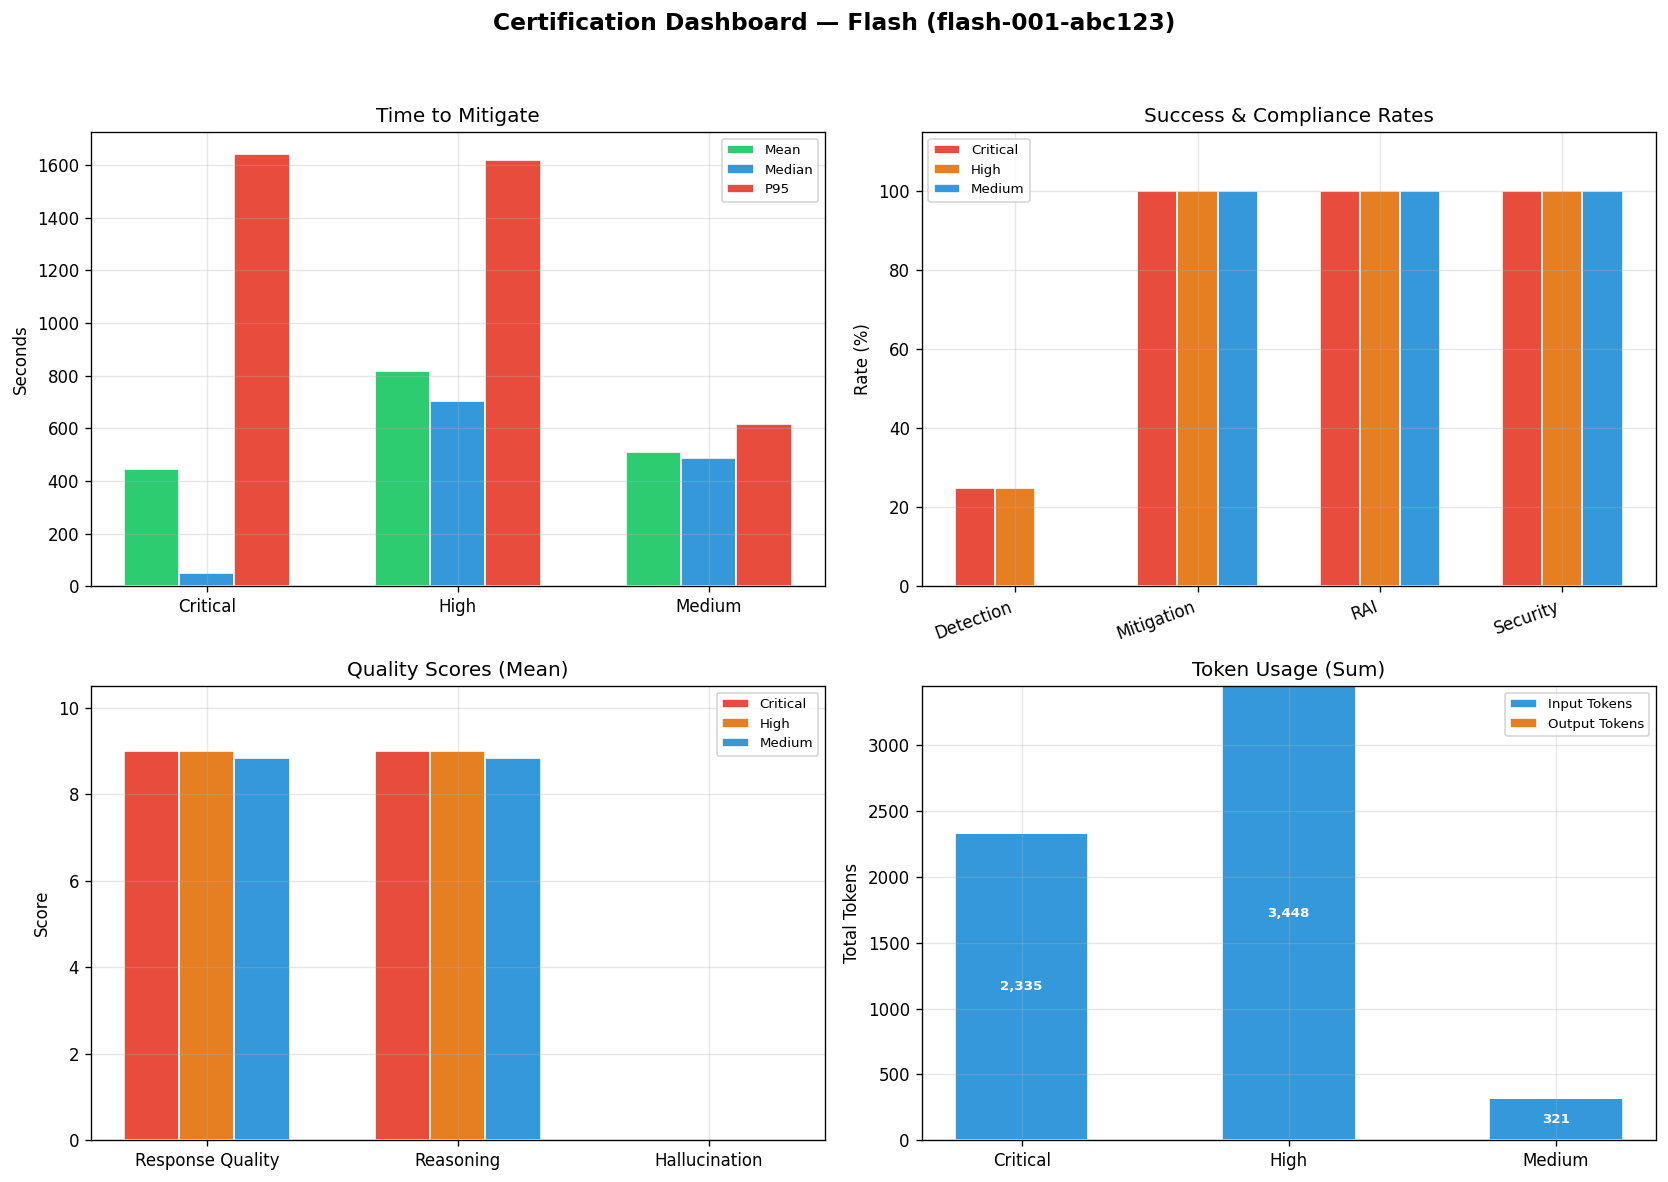

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Certification Dashboard — {AGENT_NAME} ({AGENT_ID})",
    fontsize=14, fontweight="bold",
)

x = np.arange(len(categories))
cat_labels = [c.capitalize() for c in categories]

# --- Panel 1: Time to Mitigate ---
ax = axes[0, 0]
means = [numeric_by_category[c].get("time_to_mitigate", {}).get("mean", 0) for c in categories]
medians = [numeric_by_category[c].get("time_to_mitigate", {}).get("median", 0) for c in categories]
p95s = [numeric_by_category[c].get("time_to_mitigate", {}).get("p95", 0) for c in categories]
w = 0.22
ax.bar(x - w, means, w, label="Mean", color="#2ecc71", edgecolor="white")
ax.bar(x, medians, w, label="Median", color="#3498db", edgecolor="white")
ax.bar(x + w, p95s, w, label="P95", color="#e74c3c", edgecolor="white")
ax.set_ylabel("Seconds")
ax.set_title("Time to Mitigate")
ax.set_xticks(x)
ax.set_xticklabels(cat_labels)
ax.legend(fontsize=8)

# --- Panel 2: Success & Compliance Rates ---
ax = axes[0, 1]
rate_keys = ["fault_detection_success_rate", "fault_mitigation_success_rate",
             "rai_compliance_rate", "security_compliance_rate"]
rate_short = ["Detection", "Mitigation", "RAI", "Security"]
x2 = np.arange(len(rate_keys))
offsets = np.arange(len(categories)) - (len(categories) - 1) / 2
for i, cat in enumerate(categories):
    vals = [(derived_by_category[cat].get(r) or 0) * 100 for r in rate_keys]
    ax.bar(x2 + offsets[i] * w, vals, w,
           label=cat.capitalize(), color=CATEGORY_COLORS[cat], edgecolor="white")
ax.set_ylabel("Rate (%)")
ax.set_title("Success & Compliance Rates")
ax.set_xticks(x2)
ax.set_xticklabels(rate_short, rotation=20, ha="right")
ax.set_ylim(0, 115)
ax.legend(fontsize=8)

# --- Panel 3: Quality Scores ---
ax = axes[1, 0]
q_metrics = ["response_quality_score", "reasoning_score", "hallucination_score"]
q_labels = ["Response Quality", "Reasoning", "Hallucination"]
x3 = np.arange(len(q_metrics))
for i, cat in enumerate(categories):
    vals = [numeric_by_category[cat].get(m, {}).get("mean", 0) for m in q_metrics]
    ax.bar(x3 + offsets[i] * w, vals, w,
           label=cat.capitalize(), color=CATEGORY_COLORS[cat], edgecolor="white")
ax.set_ylabel("Score")
ax.set_title("Quality Scores (Mean)")
ax.set_xticks(x3)
ax.set_xticklabels(q_labels)
ax.set_ylim(0, 10.5)
ax.legend(fontsize=8)

# --- Panel 4: Token Usage ---
ax = axes[1, 1]
input_sums = [numeric_by_category[c].get("input_tokens", {}).get("sum", 0) for c in categories]
output_sums = [numeric_by_category[c].get("output_tokens", {}).get("sum", 0) for c in categories]
bars1 = ax.bar(x, input_sums, 0.5, label="Input Tokens", color="#3498db", edgecolor="white")
bars2 = ax.bar(x, output_sums, 0.5, bottom=input_sums, label="Output Tokens", color="#e67e22", edgecolor="white")
for bar, val in zip(bars1, input_sums):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, val / 2,
                f"{val:,.0f}", ha="center", va="center", fontsize=8, fontweight="bold", color="white")
ax.set_ylabel("Total Tokens")
ax.set_title("Token Usage (Sum)")
ax.set_xticks(x)
ax.set_xticklabels(cat_labels)
ax.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 7b. Save Scorecard to JSON

In [18]:
output_path = Path(".") / f"aggregated_scorecard_{AGENT_ID}.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(final_scorecard, f, indent=4, default=str)

print(f"Scorecard saved to: {output_path.resolve()}")

Scorecard saved to: C:\Users\machary\Downloads\Work\Projects\Infosys\Agentcert\repo\AgentCert\agentcert\aggregation\notebooks\aggregated_scorecard_flash-001-abc123.json
